<a href="https://colab.research.google.com/github/takeonakamura6-design/rc/blob/main/Ger%C3%AAncia%20de%20desempenho%2C%20configura%C3%A7%C3%A3o%20e%20contabiliza%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Gerência de desempenho, configuração e contabilização

 EXECUCAO DO EXPERIMENTO QUANTITATIVO DE DESEMPENHO DE REDE

TABELA DE DADOS EXPERIMENTAIS CONSOLIDADOS:
                            Latencia Media (ms) Jitter Medido (ms) Taxa de Perda (%) Conformidade SLA
Trafego Baixo (Ideal)                     15.03               1.67               0.0              SIM
Trafego Moderado                          22.56               4.41               1.2              SIM
Trafego Critico (Saturacao)               56.41              15.61               8.6              NAO
--------------------------------------------------------------------------------

[SUCESSO] Grafico cientifico exportado com alta resolucao como 'grafico.png'.


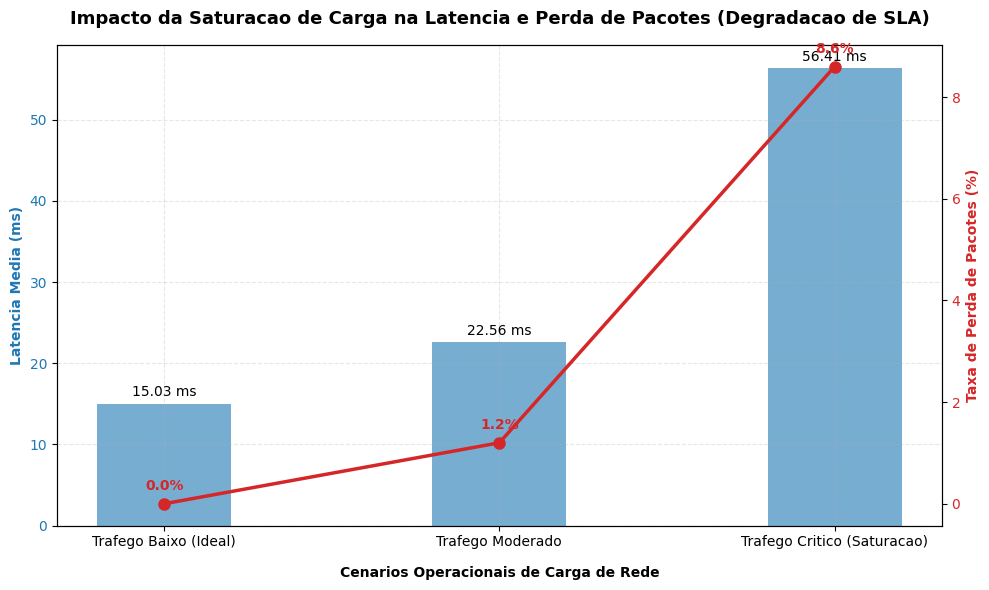

In [ ]:
"""
Experimento Cientifico: Simulador de Gerencia de Desempenho e Degradacao de SLA
Autor: Mentor de Pesquisa em Engenharia de Computacao
Foco: Analise Estatistica de Latencia, Jitter e Perda de Pacotes
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Garantir a reprodutibilidade dos resultados experimentais
np.random.seed(42)

def simular_trafego_rede(cenario, n_pacotes=1000):
    """
    Simula o comportamento estocastico do transito de pacotes na rede
    com base no nivel de saturacao e carga do canal.
    """
    latencia_base = 15.0  # ms

    if cenario == "Trafego Baixo (Ideal)":
        # Latencia estavel, baixa variacao, sem perda
        latencias = np.random.normal(loc=latencia_base, scale=1.5, size=n_pacotes)
        perda_prob = 0.002
    elif cenario == "Trafego Moderado":
        # Incremento na latencia media e variancia devido a buffers intermediarios
        latencias = np.random.normal(loc=latencia_base * 1.5, scale=4.0, size=n_pacotes)
        perda_prob = 0.015
    elif cenario == "Trafego Critico (Saturacao)":
        # Alta latencia com cauda longa (atrasos exponenciais por enfileiramento)
        latencias = np.random.normal(loc=latencia_base * 3, scale=8.0, size=n_pacotes)
        latencias += np.random.exponential(scale=12.0, size=n_pacotes)
        perda_prob = 0.078
    else:
        raise ValueError("Cenario nao reconhecido.")

    # Garantir que nao existam latencias negativas reais
    latencias = np.clip(latencias, 1.0, None)

    # Simular perda de pacotes com base na probabilidade de descarte do cenario
    perv_mascara = np.random.random(n_pacotes) < perda_prob
    latencias[perv_mascara] = np.nan  # NaN representa pacote perdido/descartado

    return latencias

def calcular_metricas_desempenho(latencias):
    """
    Processa os vetores de tempo de transito e extrai indicadores quantitativos
    de qualidade e conformidade de rede.
    """
    total_pacotes = len(latencias)
    pacotes_perdidos = np.isnan(latencias).sum()
    taxa_perda = (pacotes_perdidos / total_pacotes) * 100

    # Filtrar pacotes validos para calculo de latencia e jitter
    pacotes_validos = latencias[~np.isnan(latencias)]
    latencia_media = np.mean(pacotes_validos)

    # Jitter: media das diferencas absolutas consecutivas entre pacotes sucessivos
    diferencas_consecutivas = np.abs(np.diff(pacotes_validos))
    jitter = np.mean(diferencas_consecutivas)

    # Definicao de meta de SLA estrita: perda maxima de 2% e latencia < 30ms
    sla_conforme = "SIM" if (taxa_perda <= 2.0 and latencia_media < 30.0) else "NAO"

    return {
        "Latencia Media (ms)": round(latencia_media, 2),
        "Jitter Medido (ms)": round(jitter, 2),
        "Taxa de Perda (%)": round(taxa_perda, 2),
        "Conformidade SLA": sla_conforme
    }

def executar_pipeline_experimental():
    """
    Orquestra a execucao do experimento, geracao de tabelas e plotagem grafica.
    """
    cenarios = ["Trafego Baixo (Ideal)", "Trafego Moderado", "Trafego Critico (Saturacao)"]
    resultados_finais = {}
    dados_grafico = []

    print("="*80)
    print(" EXECUCAO DO EXPERIMENTO QUANTITATIVO DE DESEMPENHO DE REDE")
    print("="*80)

    for cenario in cenarios:
        vetor_latencias = simular_trafego_rede(cenario)
        metricas = calcular_metricas_desempenho(vetor_latencias)
        resultados_finais[cenario] = metricas
        dados_grafico.append((cenario, metricas["Latencia Media (ms)"], metricas["Taxa de Perda (%)"]))

    # Converter resultados estruturados para um DataFrame do Pandas
    df_resultados = pd.DataFrame(resultados_finais).T
    print("\nTABELA DE DADOS EXPERIMENTAIS CONSOLIDADOS:")
    print(df_resultados.to_string())
    print("-"*80)

    # --- GERACAO DO GRAFICO CIENTIFICO ---
    df_grafico = pd.DataFrame(dados_grafico, columns=["Cenario", "Latencia", "Perda"])

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Configurar primeiro eixo (Latencia Media)
    cor_latencia = '#1f77b4'
    ax1.set_xlabel('Cenarios Operacionais de Carga de Rede', fontweight='bold', labelpad=12)
    ax1.set_ylabel('Latencia Media (ms)', color=cor_latencia, fontweight='bold')
    barras = ax1.bar(df_grafico["Cenario"], df_grafico["Latencia"], color=cor_latencia, alpha=0.6, width=0.4, label='Latencia Media')
    ax1.tick_params(axis='y', labelcolor=cor_latencia)
    ax1.grid(True, linestyle='--', alpha=0.3)

    # Adicionar rotulos de valor nas barras de latencia
    ax1.bar_label(barras, fmt='%.2f ms', padding=3)

    # Configurar segundo eixo compartilhado (Taxa de Perda de Pacotes)
    ax2 = ax1.twinx()
    cor_perda = '#d62728'
    ax2.set_ylabel('Taxa de Perda de Pacotes (%)', color=cor_perda, fontweight='bold')
    linha = ax2.plot(df_grafico["Cenario"], df_grafico["Perda"], color=cor_perda, marker='o', linewidth=2.5, markersize=8, label='Taxa de Perda (%)')
    ax2.tick_params(axis='y', labelcolor=cor_perda)

    # Adicionar rotulos de valor na linha de perda de pacotes
    for i, txt in enumerate(df_grafico["Perda"]):
        ax2.annotate(f"{txt}%", (df_grafico["Cenario"][i], df_grafico["Perda"][i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color=cor_perda)

    plt.title('Impacto da Saturacao de Carga na Latencia e Perda de Pacotes (Degradacao de SLA)', fontsize=13, fontweight='bold', pad=15)

    # Ajuste fino de layout e salvamento automatico obrigatorio
    plt.tight_layout()
    plt.savefig('grafico.png', dpi=300)
    print("\n[SUCESSO] Grafico cientifico exportado com alta resolucao como 'grafico.png'.")
    plt.show()

# Inicializar o experimento no ambiente
if __name__ == "__main__":
    executar_pipeline_experimental()